# So sánh các model GRPO trên Kaggle

Notebook này đọc cấu hình `grpo.yaml` và các file training metrics từ mỗi thư mục model trong `dataset_path`.
Nó tạo biến nhận diện theo đặc điểm model, lưu cấu hình và kết quả training để so sánh loss, step metrics và hiệu năng.

In [1]:
from pathlib import Path
import json
import os
import pandas as pd
import yaml

# Đường dẫn dataset trên Kaggle
dataset_path = Path("/kaggle/input/datasets/qucnguyntin/kaggle-data/Kaggle_data")
if not dataset_path.exists():
    dataset_path = Path("Kaggle_data")

print("dataset_path:", dataset_path)
print("exists:", dataset_path.exists())

model_dirs = sorted([p for p in dataset_path.iterdir() if p.is_dir()])
print("Found model folders:", [p.name for p in model_dirs])

dataset_path: /kaggle/input/datasets/qucnguyntin/kaggle-data/Kaggle_data
exists: True
Found model folders: ['results-qwen_1', 'results_deepseek_1', 'results_deepseek_2', 'results_qwen_2']


In [2]:
def load_yaml(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def parse_txt_metrics(path: Path):
    result = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if ":" not in line:
                continue
            key, value = line.split(":", 1)
            key = key.strip()
            value = value.strip()
            try:
                result[key] = float(value)
            except ValueError:
                result[key] = value
    return result


def model_signature(config: dict):
    parts = []
    base = config.get("model_name_or_path", "unknown").replace("/", "_")
    parts.append(base)
    dtype = config.get("torch_dtype") or config.get("dtype") or "unknown_dtype"
    parts.append(dtype)
    lr = config.get("learning_rate")
    if lr is not None:
        parts.append(f"lr{lr}")
    max_steps = config.get("max_steps")
    if max_steps is not None:
        parts.append(f"steps{max_steps}")
    max_completion = config.get("max_completion_length")
    if max_completion is not None:
        parts.append(f"maxc{max_completion}")
    if config.get("bf16"):
        parts.append("bf16")
    if config.get("fp16"):
        parts.append("fp16")
    return "__".join(parts)


def try_load_csv(path: Path):
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except Exception as exc:
        print(f"Cannot read CSV {path}: {exc}")
        return None


model_data_by_key = {}

for model_dir in model_dirs:
    grpo_path = model_dir / "grpo.yaml"
    if not grpo_path.exists():
        print("Skipped missing grpo.yaml:", model_dir)
        continue

    config = load_yaml(grpo_path)
    key = model_signature(config)
    key = key.replace(" ", "_")

    if key in model_data_by_key:
        key = f"{key}__{model_dir.name}"

    step_metrics_path = model_dir / "step_metrics.csv"
    train_results_path = model_dir / "train_results.json"
    training_metrics_path = model_dir / "training_metrics.txt"

    step_metrics = try_load_csv(step_metrics_path)
    train_results = None
    if train_results_path.exists():
        with train_results_path.open("r", encoding="utf-8") as f:
            train_results = json.load(f)

    training_metrics = None
    if training_metrics_path.exists():
        training_metrics = parse_txt_metrics(training_metrics_path)

    # Additional files với thông tin metrics / results tương tự
    extra_info = {}
    for candidate in model_dir.glob("*.json"):
        if candidate.name not in {"train_results.json", "all_results.json", "tokenizer.json"}:
            try:
                payload = json.loads(candidate.read_text(encoding="utf-8"))
                extra_info[candidate.name] = payload
            except Exception:
                pass

    model_data_by_key[key] = {
        "folder": model_dir.name,
        "path": str(model_dir),
        "config": config,
        "step_metrics": step_metrics,
        "train_results": train_results,
        "training_metrics": training_metrics,
        "extra_json": extra_info,
    }

    globals()[key] = model_data_by_key[key]

print("Loaded models:", list(model_data_by_key.keys()))

Loaded models: ['Qwen_Qwen3.5-0.8B__float16__lr1e-06__steps20__maxc512__bf16', 'deepseek-ai_DeepSeek-R1-Distill-Qwen-1.5B__float16__lr1e-05__steps100__maxc1024__fp16', 'deepseek-ai_DeepSeek-R1-Distill-Qwen-1.5B__float16__lr1e-06__steps20__maxc1024__bf16', 'Qwen_Qwen3.5-0.8B__float16__lr2e-06__steps20__maxc1024__bf16']


In [3]:
pd.set_option("display.max_columns", None)

summary_rows = []
for key, item in model_data_by_key.items():
    cfg = item["config"]
    final_loss = None
    if item["step_metrics"] is not None and "loss" in item["step_metrics"].columns:
        loss_series = item["step_metrics"]["loss"].dropna()
        if not loss_series.empty:
            final_loss = float(loss_series.iloc[-1])

    train_loss = None
    if item["train_results"] is not None:
        train_loss = item["train_results"].get("train_loss")

    row = {
        "key": key,
        "folder": item["folder"],
        "model_name_or_path": cfg.get("model_name_or_path"),
        "torch_dtype": cfg.get("torch_dtype"),
        "bf16": cfg.get("bf16"),
        "fp16": cfg.get("fp16"),
        "learning_rate": cfg.get("learning_rate"),
        "max_steps": cfg.get("max_steps"),
        "max_completion_length": cfg.get("max_completion_length"),
        "save_steps": cfg.get("save_steps"),
        "final_step_loss": final_loss,
        "train_loss": train_loss,
        "train_runtime": item["train_results"].get("train_runtime") if item["train_results"] else None,
        "train_samples_per_second": item["train_results"].get("train_samples_per_second") if item["train_results"] else None,
    }
    if item["training_metrics"]:
        row.update(item["training_metrics"])

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["max_steps", "learning_rate", "train_loss"], ascending=[False, True, True])
summary_df

,key,folder,model_name_or_path,torch_dtype,bf16,fp16,learning_rate,max_steps,max_completion_length,save_steps,final_step_loss,train_loss,train_runtime,train_samples_per_second,total_size_before (MB),total_size_after (MB),total_time (seconds),ram_peak (MB),ram_consump (MB),disk_storage (MB)
1,deepseek-ai_DeepSeek-R1-Distill-Qwen-1.5B__flo...,results_deepseek_1,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,float16,False,True,0.000010,100,1024,50,0.000022,0.001352,36067.9715,0.044,3424.75,3407.14,36073.19,5853.69,3485.15,333.13
2,deepseek-ai_DeepSeek-R1-Distill-Qwen-1.5B__flo...,results_deepseek_2,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,float16,True,False,0.000001,20,1024,50,-0.000001,-0.000003,16301.2017,0.020,3424.75,3407.14,16314.67,5845.76,3476.35,180.81
0,Qwen_Qwen3.5-0.8B__float16__lr1e-06__steps20__...,results-qwen_1,Qwen/Qwen3.5-0.8B,float16,True,False,0.000001,20,512,50,0.000273,0.010431,9458.0577,0.034,1455.72,1445.40,9466.33,3499.90,1492.71,616.56
3,Qwen_Qwen3.5-0.8B__float16__lr2e-06__steps20__...,results_qwen_2,Qwen/Qwen3.5-0.8B,float16,True,False,0.000002,20,1024,50,0.001777,-0.006107,18644.4882,0.017,1455.72,1445.40,18652.94,4520.88,1492.77,616.56


In [4]:
# In ra chi tiết step metrics cho mỗi model để so sánh
for key, item in model_data_by_key.items():
    print("\n===", key, "===")
    if item["step_metrics"] is None:
        print("No step_metrics.csv")
        continue

    df = item["step_metrics"]
    if "loss" in df.columns:
        print("steps:", len(df), "final loss:", df["loss"].dropna().iloc[-1])
        display(df.tail(5))
    else:
        print("step_metrics.csv lacks loss column")

    if item["training_metrics"]:
        print("training_metrics:", item["training_metrics"])
    if item["train_results"]:
        print("train_results:", {k: item["train_results"].get(k) for k in ["train_loss", "train_runtime", "train_samples_per_second"]})


=== Qwen_Qwen3.5-0.8B__float16__lr1e-06__steps20__maxc512__bf16 ===
steps: 21 final loss: 0.0002729222178459


,step,epoch,loss,learning_rate,grad_norm,rewards/format_reward,rewards/cosine_scaled_reward,reward,reward_std,gpu_mem_alloc_mb,gpu_mem_peak_mb,step_time_sec
16,17,0.0097,0.024725,2.052800e-07,NaN,0.0,-0.435053,-0.870107,0.189374,1565.2,3669.9,469.71
17,18,0.0103,0.000237,1.602886e-07,NaN,0.0,-0.410039,-0.820078,0.261571,1565.2,3669.9,472.28
18,19,0.0109,0.016676,1.271383e-07,NaN,0.0,-0.411685,-0.823370,0.200136,1565.2,3669.9,477.29
19,20,0.0114,0.000273,1.068365e-07,NaN,0.0,-0.402208,-0.804416,0.242351,1565.2,3669.9,473.18
20,20,0.0114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1565.2,3669.9,477.00


training_metrics: {'total_size_before (MB)': 1455.72, 'total_size_after (MB)': 1445.4, 'total_time (seconds)': 9466.33, 'ram_peak (MB)': 3499.9, 'ram_consump (MB)': 1492.71, 'disk_storage (MB)': 616.56}
train_results: {'train_loss': 0.010430806130170823, 'train_runtime': 9458.0577, 'train_samples_per_second': 0.034}

=== deepseek-ai_DeepSeek-R1-Distill-Qwen-1.5B__float16__lr1e-05__steps100__maxc1024__fp16 ===
steps: 101 final loss: 2.2009015083312988e-05


,step,epoch,loss,learning_rate,grad_norm,rewards/format_reward,rewards/cosine_scaled_reward,reward,reward_std,gpu_mem_alloc_mb,gpu_mem_peak_mb,step_time_sec
96,97,0.0554,0.000015,0.000002,NaN,0.0,-0.460876,-0.921752,0.055481,3654.5,6138.0,357.98
97,98,0.0560,0.000020,0.000001,NaN,0.0,-0.470722,-0.941444,0.057337,3654.4,6138.0,359.07
98,99,0.0566,0.000017,0.000001,NaN,0.0,-0.434240,-0.868480,0.184904,3654.4,6138.0,357.48
99,100,0.0571,0.000022,0.000001,NaN,0.0,-0.448389,-0.896779,0.127915,3654.4,6138.0,358.57
100,100,0.0571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3654.4,6138.0,362.18


training_metrics: {'total_size_before (MB)': 3424.75, 'total_size_after (MB)': 3407.14, 'total_time (seconds)': 36073.19, 'ram_peak (MB)': 5853.69, 'ram_consump (MB)': 3485.15, 'disk_storage (MB)': 333.13}
train_results: {'train_loss': 0.0013520326372236013, 'train_runtime': 36067.9715, 'train_samples_per_second': 0.044}

=== deepseek-ai_DeepSeek-R1-Distill-Qwen-1.5B__float16__lr1e-06__steps20__maxc1024__bf16 ===
steps: 21 final loss: -1.460779458284378e-06


,step,epoch,loss,learning_rate,grad_norm,rewards/format_reward,rewards/cosine_scaled_reward,reward,reward_std,gpu_mem_alloc_mb,gpu_mem_peak_mb,step_time_sec
16,17,0.0097,-2.101064e-06,2.052800e-07,NaN,0.0,-0.281066,-0.562131,0.371349,3645.2,6129.7,815.13
17,18,0.0103,-1.752749e-06,1.602886e-07,NaN,0.0,-0.256715,-0.513430,0.343254,3645.2,6129.7,815.46
18,19,0.0109,-2.980232e-07,1.271383e-07,NaN,0.0,-0.205688,-0.411376,0.289296,3645.2,6129.7,816.18
19,20,0.0114,-1.460779e-06,1.068365e-07,NaN,0.0,-0.315051,-0.630102,0.332873,3645.2,6129.7,815.67
20,20,0.0114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3645.2,6129.7,819.40


training_metrics: {'total_size_before (MB)': 3424.75, 'total_size_after (MB)': 3407.14, 'total_time (seconds)': 16314.67, 'ram_peak (MB)': 5845.76, 'ram_consump (MB)': 3476.35, 'disk_storage (MB)': 180.81}
train_results: {'train_loss': -3.18021047860384e-06, 'train_runtime': 16301.2017, 'train_samples_per_second': 0.02}

=== Qwen_Qwen3.5-0.8B__float16__lr2e-06__steps20__maxc1024__bf16 ===
steps: 21 final loss: 0.0017768293619155


,step,epoch,loss,learning_rate,grad_norm,rewards/format_reward,rewards/cosine_scaled_reward,reward,reward_std,gpu_mem_alloc_mb,gpu_mem_peak_mb,step_time_sec
16,17,0.0097,-0.008978,4.105600e-07,NaN,0.0,-0.095641,-0.191282,0.163794,1565.3,4740.5,929.90
17,18,0.0103,-0.035456,3.205771e-07,NaN,0.0,-0.176338,-0.352675,0.257407,1565.3,4740.5,878.76
18,19,0.0109,0.001573,2.542766e-07,NaN,0.0,-0.095236,-0.190473,0.183898,1565.3,4740.5,934.27
19,20,0.0114,0.001777,2.136730e-07,NaN,0.0,-0.118502,-0.237004,0.272347,1565.3,4740.5,934.07
20,20,0.0114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1565.3,4740.5,937.48


training_metrics: {'total_size_before (MB)': 1455.72, 'total_size_after (MB)': 1445.4, 'total_time (seconds)': 18652.94, 'ram_peak (MB)': 4520.88, 'ram_consump (MB)': 1492.77, 'disk_storage (MB)': 616.56}
train_results: {'train_loss': -0.00610662829130888, 'train_runtime': 18644.4882, 'train_samples_per_second': 0.017}


## Phân tích và so sánh kết quả

Biểu đồ dưới đây sẽ giúp so sánh:
- `train_loss` giữa các model
- `final_step_loss` từ `step_metrics.csv`
- Tiến trình loss theo step cho mỗi model

/tmp/ipykernel_57/1272225927.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


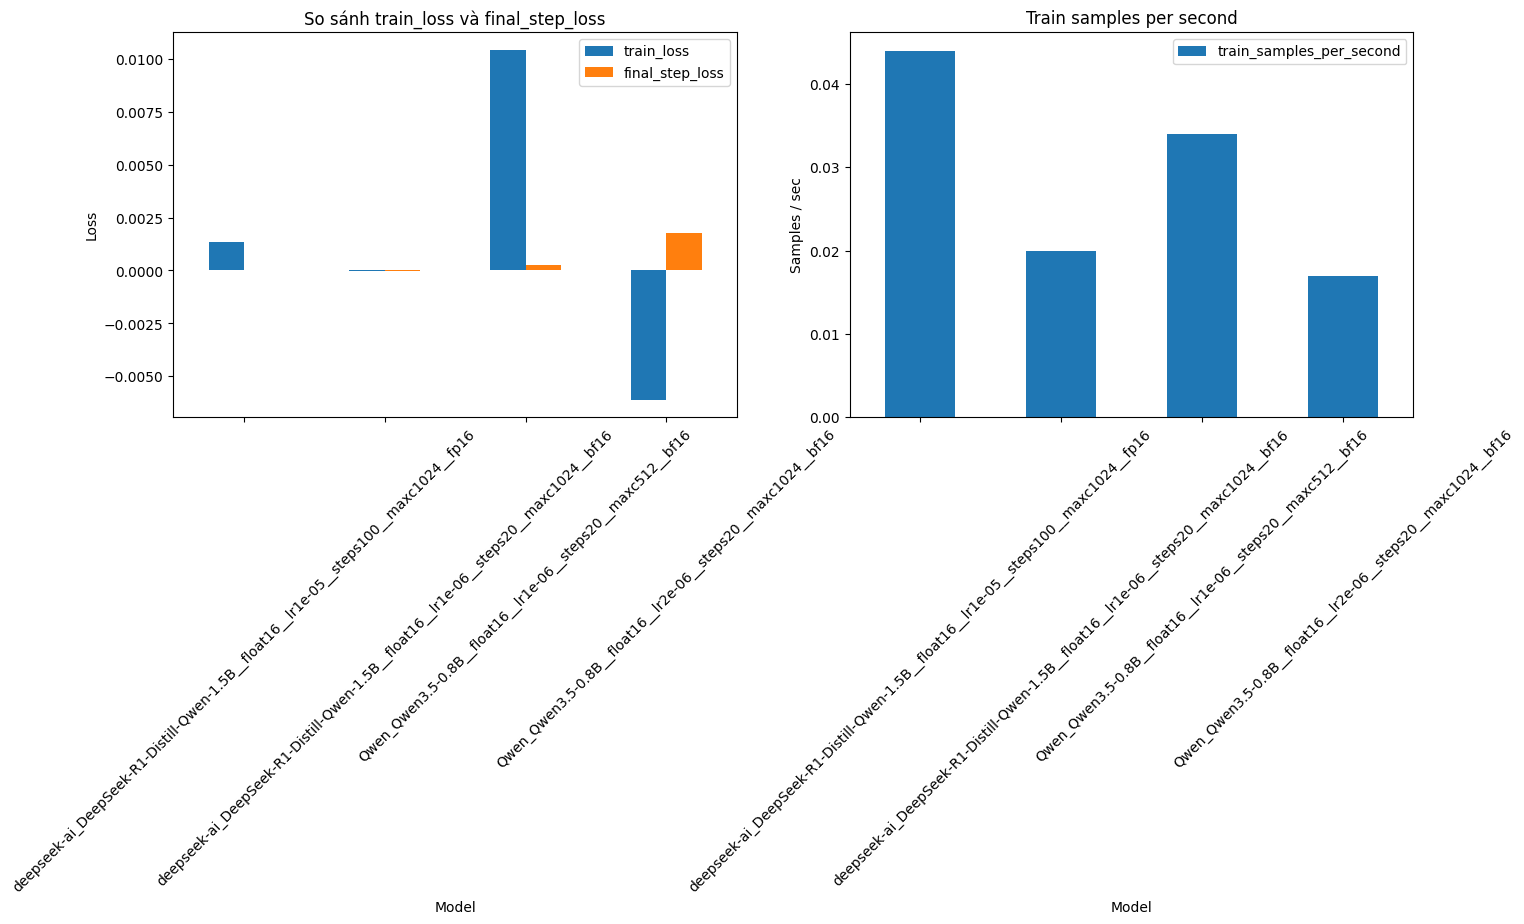


--- Tóm tắt model tốt nhất ---
Model có train_loss nhỏ nhất:


key                         Qwen_Qwen3.5-0.8B__float16__lr2e-06__steps20__...
folder                                                         results_qwen_2
model_name_or_path                                          Qwen/Qwen3.5-0.8B
torch_dtype                                                           float16
bf16                                                                     True
fp16                                                                    False
learning_rate                                                        0.000002
max_steps                                                                  20
max_completion_length                                                    1024
save_steps                                                                 50
final_step_loss                                                      0.001777
train_loss                                                          -0.006107
train_runtime                                                   

Model có final_step_loss nhỏ nhất:


key                         deepseek-ai_DeepSeek-R1-Distill-Qwen-1.5B__flo...
folder                                                     results_deepseek_2
model_name_or_path                  deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
torch_dtype                                                           float16
bf16                                                                     True
fp16                                                                    False
learning_rate                                                        0.000001
max_steps                                                                  20
max_completion_length                                                    1024
save_steps                                                                 50
final_step_loss                                                     -0.000001
train_loss                                                          -0.000003
train_runtime                                                   

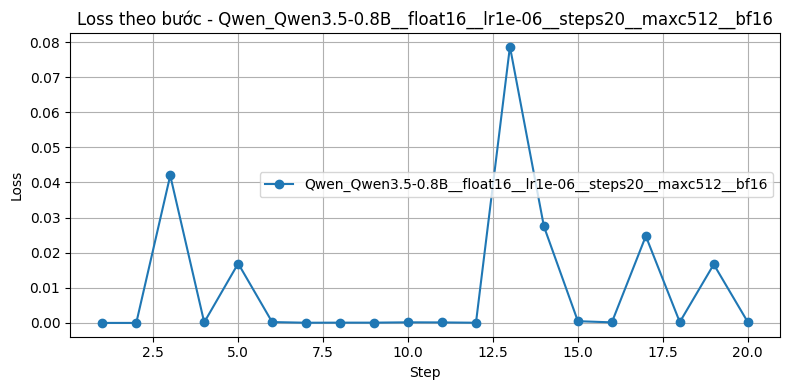

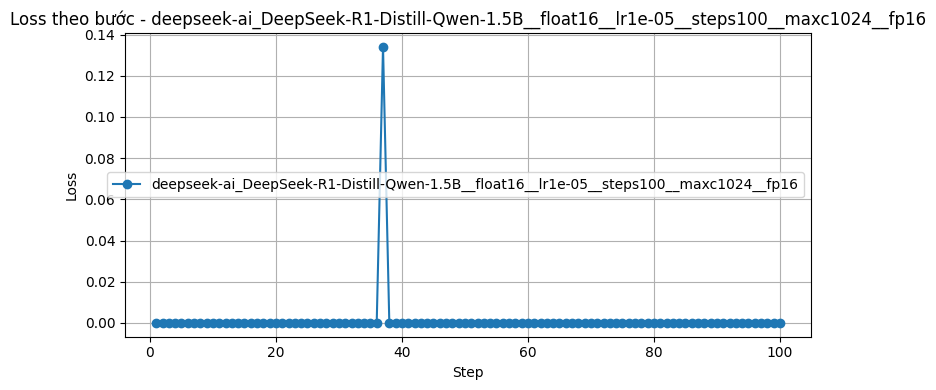

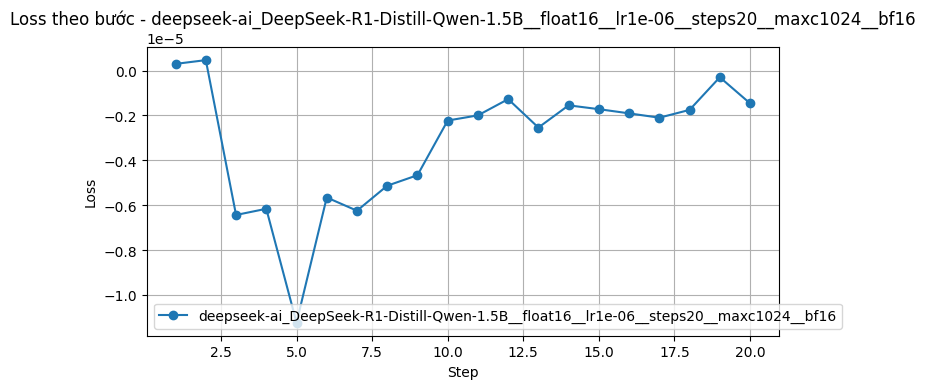

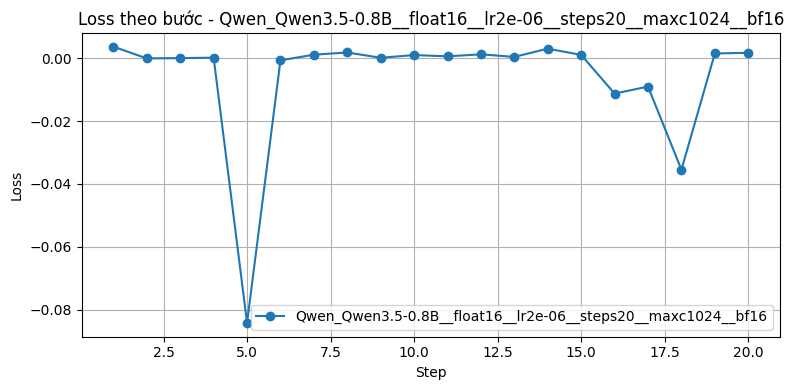

In [5]:
import matplotlib.pyplot as plt

if summary_df.empty:
    print("Không có dữ liệu để vẽ.")
else:
    summary_plot = summary_df.copy()
    summary_plot = summary_plot.reset_index(drop=True)

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    summary_plot.plot(
        x="key",
        y=["train_loss", "final_step_loss"],
        kind="bar",
        ax=ax[0],
        title="So sánh train_loss và final_step_loss",
        rot=45,
        fontsize=10,
        legend=True,
        ylabel="Loss"
    )
    ax[0].set_xlabel("Model")
    ax[0].tick_params(axis="x", labelrotation=45)

    metrics_cols = [c for c in summary_plot.columns if c not in {"key", "folder", "model_name_or_path", "torch_dtype", "bf16", "fp16", "train_runtime", "train_samples_per_second", "max_steps", "max_completion_length", "save_steps"}]
    if "train_samples_per_second" in summary_plot.columns and summary_plot["train_samples_per_second"].notna().any():
        summary_plot.plot(
            x="key",
            y="train_samples_per_second",
            kind="bar",
            ax=ax[1],
            title="Train samples per second",
            rot=45,
            ylabel="Samples / sec"
        )
        ax[1].set_xlabel("Model")
        ax[1].tick_params(axis="x", labelrotation=45)
    else:
        ax[1].text(0.5, 0.5, "Không có dữ liệu train_samples_per_second", ha="center", va="center")
        ax[1].set_axis_off()

    plt.tight_layout()
    plt.show()

    print("\n--- Tóm tắt model tốt nhất ---")
    if "train_loss" in summary_plot.columns and summary_plot["train_loss"].notna().any():
        best_train = summary_plot.loc[summary_plot["train_loss"].idxmin()]
        print("Model có train_loss nhỏ nhất:")
        display(best_train)
    if "final_step_loss" in summary_plot.columns and summary_plot["final_step_loss"].notna().any():
        best_step = summary_plot.loc[summary_plot["final_step_loss"].idxmin()]
        print("Model có final_step_loss nhỏ nhất:")
        display(best_step)

    for key, item in model_data_by_key.items():
        df = item["step_metrics"]
        if df is None or "loss" not in df.columns:
            continue
        plt.figure(figsize=(8, 4))
        plt.plot(df["step"], df["loss"], marker="o", label=key)
        plt.title(f"Loss theo bước - {key}")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()